   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Decision Tree Accuracy: 0.9853658536585366
Limited Depth Tree Accuracy: 0.8


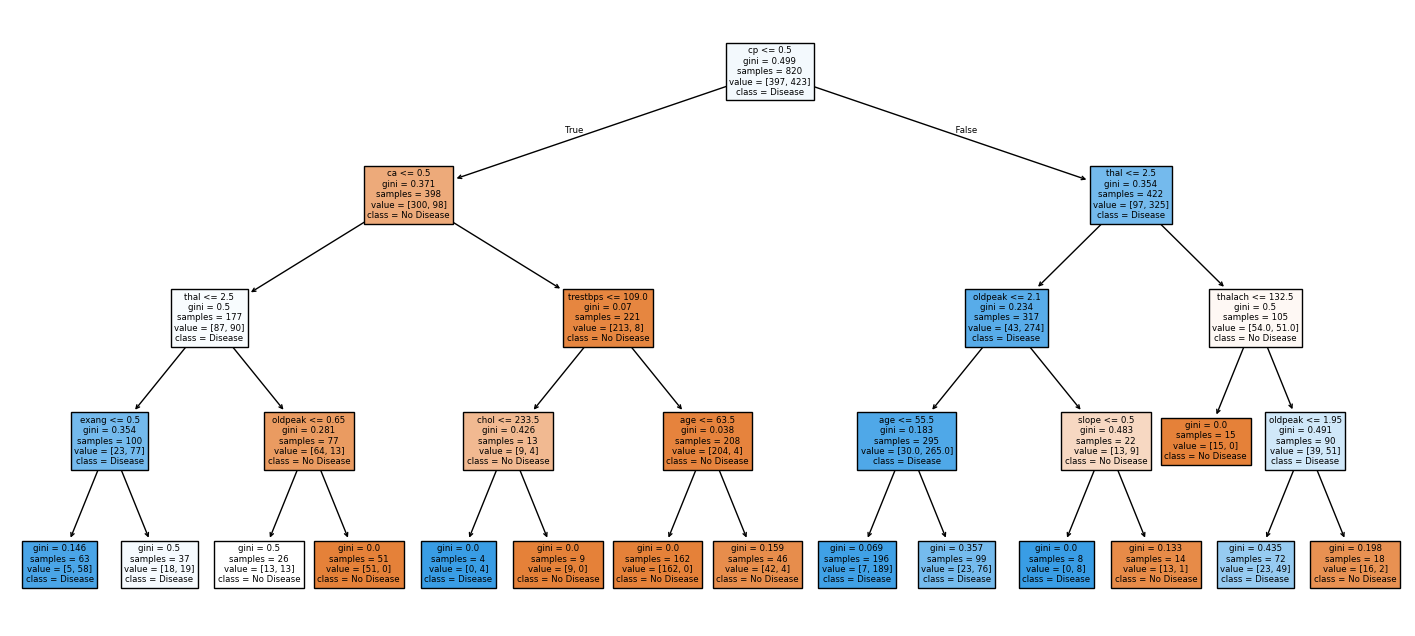


Random Forest Accuracy: 0.9853658536585366

Top Features:
    Feature  Importance
2        cp    0.135072
11       ca    0.127327
7   thalach    0.122169
9   oldpeak    0.121905
12     thal    0.110518

Cross Validation Score: 0.9970731707317073


In [1]:
# Task 5: Decision Trees & Random Forests - Heart Disease Dataset

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

print(df.head())

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- DECISION TREE ----------------

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))

# Limit depth to avoid overfitting
dt_limited = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_limited.fit(X_train, y_train)

dt_limited_pred = dt_limited.predict(X_test)
print("Limited Depth Tree Accuracy:",
      accuracy_score(y_test, dt_limited_pred))

# Visualize Tree
plt.figure(figsize=(18,8))
plot_tree(dt_limited,
          feature_names=X.columns,
          class_names=["No Disease","Disease"],
          filled=True)
plt.show()

# ---------------- RANDOM FOREST ----------------

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importance.head())

# ---------------- CROSS VALIDATION ----------------

cv = cross_val_score(rf, X, y, cv=5)
print("\nCross Validation Score:", cv.mean())